# Proyecto 2
#### Martín Carrera & Juan Matías Leon

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"/Users/elcarrera/Desktop/Python/Recogida Y Bases de Datos/Datasets de calse")

Titanic = pd.read_csv("Titanic_2.csv", sep=",")

Weather = pd.read_csv("condiciones_meteorologicas.csv", sep=",")


In [88]:
Weather

,Ship_ID,Nombre_Barco,Fecha_Salida,Tripulantes,Clima,TemperaturaMedia
0,1,TITANIC,1912-04-10,892,Despejado,2.0
1,2,OLYMPIC,1911-06-14,860,Nublado,10.0
2,3,BRITANNIC,1915-12-23,950,Lluvioso,8.0


In [89]:
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Barco
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Titanic
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Titanic
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Titanic
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",femalee,35.0,1,0,113803,53.1000,C123,S,Titanic
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Titanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Titanic
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Titanic
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Titanic
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Titanic


# 1.- Variables poco relevantes (0.5 puntos)

Examina todas las variables del dataset e indica cuáles crees que inicialmente no van a
aportan valor predictivo o son redundantes. Justifica tu elección.


In [90]:
Titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.690714,0.523008,0.381594,32.157014
std,257.353842,0.486592,0.836071,14.543689,1.102743,0.806057,49.724007
min,1.000000,0.000000,1.000000,-3.000000,0.000000,0.000000,-13.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [91]:
Weather.describe()

,Ship_ID,Tripulantes,TemperaturaMedia
count,3.0,3.000000,3.000000
mean,2.0,900.666667,6.666667
std,1.0,45.621632,4.163332
min,1.0,860.000000,2.000000
25%,1.5,876.000000,5.000000
50%,2.0,892.000000,8.000000
75%,2.5,921.000000,9.000000
max,3.0,950.000000,10.000000


In [92]:
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Barco           object
dtype: object

In [93]:
Titanic["Barco"].value_counts()

Barco
Titanic    891
Name: count, dtype: int64

Viendo las variables del dataset del Titanic, podemos por ejemplo que la variable ``Barco`` no sirve de nada, ya que todos son del barco del titanic. Aunque, despues, para ver hacer la union, no podemos eliminarla, ya que con ella haremos el join. Despues, la variable de ``Name``, a menos que querramos contar la cantidad de Mr y Mrs, los nombres no me aportan nada, en especial, ya tenemos la columna de ``Sex``. Despues, la columna de ``PassengerId`` no aporta mucho, ya que con ella no hacemos nada de uniones o calculos. 

## 2.- Valores perdidos (2 puntos)

• Calcula el porcentaje de valores perdidos por variable.

• Evalúa si sería conveniente eliminar TODOS los registros que contengan algún valor NaN

en alguna de las variables:

• ¿Qué porcentaje de registros se perdería?

• ¿Crees que en este caso es una opción razonable? Justifica tu decisión y aplica los cambios que consideres oportunos.

• Imputa los valores faltantes aplicando el método que consideres oportuno. Justifica tu elección.

• Comprueba que no queden valores NaN y analiza si las distribuciones cambian
significativamente tras imputar.

In [94]:

# Calcular porcentaje de valores perdidos por variable
porcentaje_perdidos = (Titanic.isnull().sum() / len(Titanic)) * 100

# Crear tabla resumen
tabla_perdidos = pd.DataFrame({
    "Valores perdidos": Titanic.isnull().sum(),
    "Porcentaje (%)": porcentaje_perdidos
}).sort_values("Porcentaje (%)", ascending=False)

print(tabla_perdidos)


             Valores perdidos  Porcentaje (%)
Cabin                     687       77.104377
Age                       177       19.865320
Embarked                    2        0.224467
PassengerId                 0        0.000000
Survived                    0        0.000000
Pclass                      0        0.000000
Name                        0        0.000000
Sex                         0        0.000000
SibSp                       0        0.000000
Parch                       0        0.000000
Ticket                      0        0.000000
Fare                        0        0.000000
Barco                       0        0.000000


En este caso, podemos ver que la variable con más valores faltantes es ``Cabin``, con 77.1% de celdas que son faltantes. Despues ``Age`` tiene 19.9% celdas vacias. Finalmente, tenemos que ``Embarked`` tiene apenas un 0.22%

Por estos porcentajes, no vemos conveniente eliminar todos los registros que tengan NaN. Por ejemplo, si hiciemos eso, con la variable  ``Cabin`` con 77.1%, sería eliminarnos 77.1% de todos los registros, dejandonos con una cantidad poco util para un futuro analisis o modelaje. Variables que ``Embarked`` tiene apenas un 0.22% se podrían eliminar, pero ya veremos que mejor usaremos una tecnica para llenarlos, al igual que ``Age`` con 19.9% celdad NaN.

Lo que hariamos, es eliminar la columna ``Cabin``, ya que con ese porcentaje tan alto, conviene mejor quitarla, y mejor tratar con aquellos con un porcentaje más bajos. 



In [95]:
# Eliminando la columna Cabin

Titanic = Titanic.drop(columns=["Cabin"])

Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Barco
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Titanic
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Titanic
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Titanic
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",femalee,35.0,1,0,113803,53.1000,S,Titanic
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Titanic
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Titanic
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Titanic
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,Titanic
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Titanic


In [96]:
Titanic["Age"] = Titanic["Age"].fillna(round(Titanic["Age"].median(), 0))

Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Barco
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Titanic
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Titanic
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Titanic
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",femalee,35.0,1,0,113803,53.1000,S,Titanic
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Titanic
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Titanic
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Titanic
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Titanic
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Titanic


Como vemos que ``Age`` es una variable numerica, para los valores faltantes decidimos sustituirlos por la mediana de las edades, asi evitamos que las edades que son outliers distorzionen la medida, ya que la media puede sufrir de esto 

In [97]:
Titanic["Embarked"] = Titanic["Embarked"].fillna(Titanic["Embarked"].mode()[0])

Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Barco
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Titanic
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Titanic
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Titanic
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",femalee,35.0,1,0,113803,53.1000,S,Titanic
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Titanic
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Titanic
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Titanic
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Titanic
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Titanic


Aqui, como ``Embarked`` es una variable categorica, decidimos que para aquellas pocas celdas con valores NaN, las llenamos con la moda, osea, del puerto de donde embarcaban más personas al Titanic. Es una medida apropiada, ya que no altera tanto por el hecho de ser tan pocas celdad con valores NaN 

Ahora chequeamos que no haya valores faltantes:

In [98]:
Titanic.isnull().any().any()

np.False_

Con esto acabamos nuestra limpieza de valores faltantes

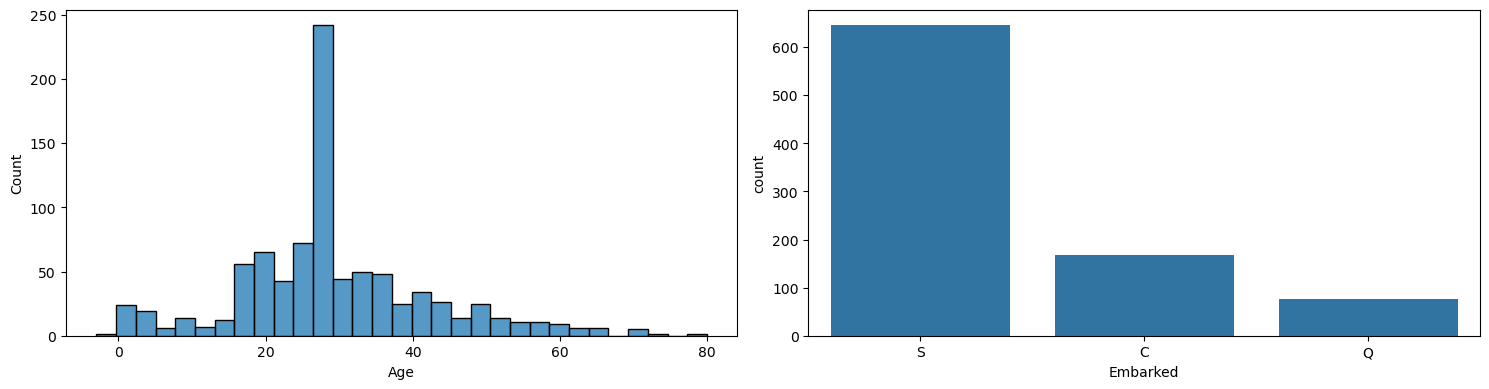

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(x="Age", data=Titanic, ax=axes[0])
sns.countplot(x="Embarked", data=Titanic, ax=axes[1])

plt.tight_layout()
plt.show()


Aqui vemos que con la variable ``Age`` al sustituir los NaN (20% de las celdas) con la mediana, claramamente vemos ese gran pico, ya que estamos agregando mas individuos con esa edad. No podríamos decir por ahora que ninguna sigue una dsitribucion normal o simetrica. 

# 3.- Correcciones ortográficas (0.5 punto)

• Selecciona las variables categóricas o de tipo texto.

• Revisa que no existan errores tipográficos. En caso de detectar errores, corrígelos.

In [100]:
variables_categoricas = Titanic.select_dtypes(include=["object"]).columns
print(variables_categoricas)


Index(['Name', 'Sex', 'Ticket', 'Embarked', 'Barco'], dtype='object')


In [101]:
Titanic["Sex"].value_counts()



Sex
male       574
female     312
mal          2
femalee      1
malee        1
femle        1
Name: count, dtype: int64

In [102]:
Titanic["Sex"] = Titanic["Sex"].replace({
    "mal": "male",
    "femalee": "female",
    "malee": "male",
    "femle": "female"
})

Titanic["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

Aqui vemos como la variable ``Sex`` tenía ciertos errores tipograficos. Esta variable solo debería tomar 2 valores, como solo hay dos sexos, pero habían errores de texto. Esto hubiese sido un problema, si en nuestro modelo o analisis querremos analizar en base a los sexos, ya que tendríamos un analisis de 2+ sexos, lo cual sería erroneo. 

# 4.- Valores extremos (outliers) (2 puntos)
• Selecciona las variables numéricas.

• ¿Qué gráfico consideras que es el más adecuado para detectar valores extremos? Realiza
dicho gráfico para las variables numéricas seleccionadas. Dame una descripción detallada
de cada uno de ellos.

• Analiza los gráficos junto con la descripción inicial de los datos e indica:

In [103]:
variables_numericas = Titanic.select_dtypes(include=["number"]).columns
print(variables_numericas)


Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


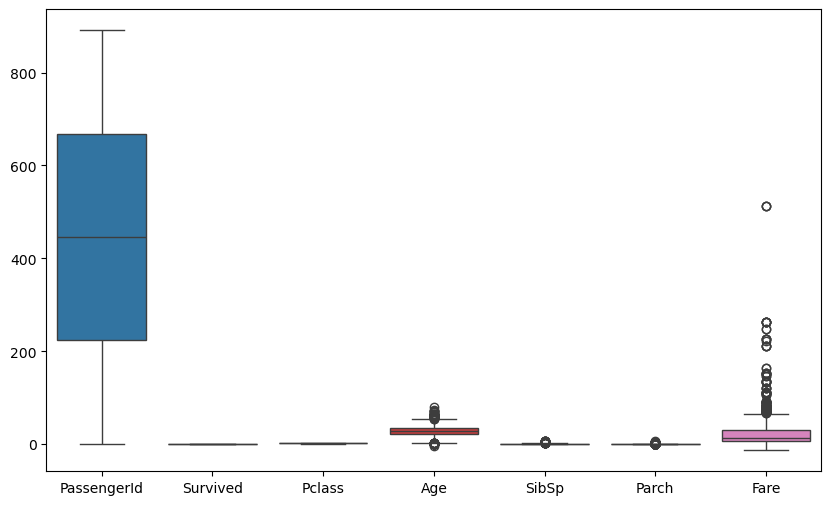

In [104]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic[variables_numericas])
plt.show()


Una forma visual muy útil de identificar posibles outliers es mediante un boxplot, ya que resume la distribución de una variable. En esta gráfica, la línea dentro de la caja representa la mediana, mientras que el borde inferior y superior de la caja corresponden al primer cuartil (Q1) y al tercer cuartil (Q3). Los bigotes muestran el rango de valores no atípicos, y los puntos que quedan fuera de esos bigotes se consideran posibles outliers. De esta manera, el boxplot permite ver en qué variables hay valores atípicos y hacia qué lado de la distribución se encuentran.

En este caso, vamos a tener que distribuir en varias graficas los boxplots, ya que variables como ``PassengerId``, ``Fare`` y ``Age`` alteran mucha la grafica, ya que tiene rangos de valores más altos que los demas, y sus outliers comprimen al resto. 

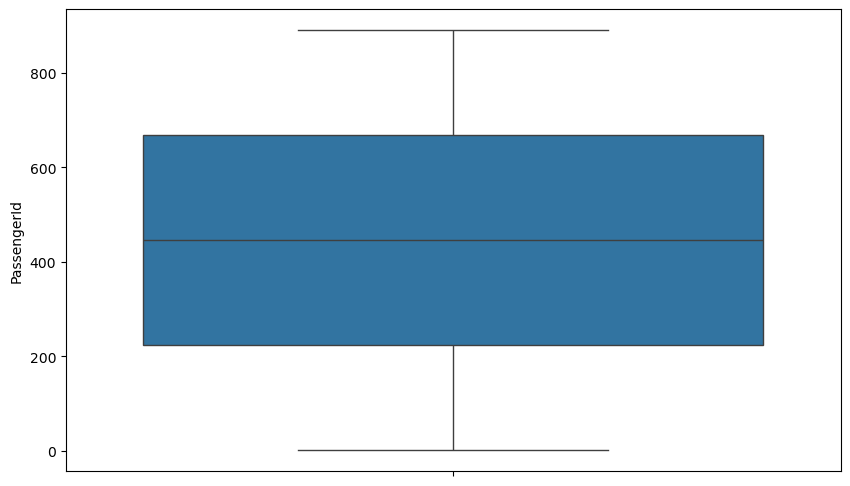

In [105]:
# Boxplot de PassengerID

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic["PassengerId"])
plt.xticks(rotation=45)
plt.show()


``PassengerId``
Aqui, claramente, como se ve la distribucion de una variable de identificador no me indica nada, por lo que sacar conclusiones de ella no me sirve nada. 

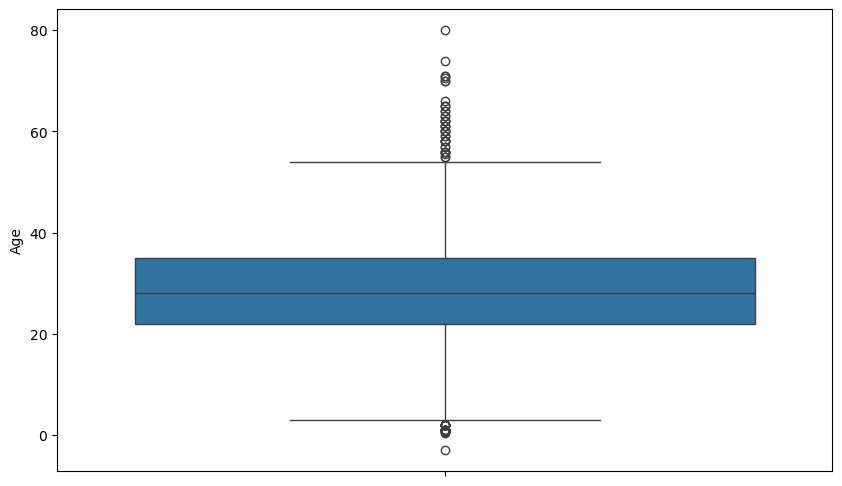

In [106]:
# Boxplot de Age

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic["Age"])
plt.xticks(rotation=45)
plt.show()

``Age``

La variable Age muestra una distribución centrada en edades adultas jóvenes. La mediana, representada por la línea dentro de la caja, se encuentra aproximadamente en los 28 años, lo que indica que la mitad de los pasajeros tenía menos de esa edad y la otra mitad más.

En cuanto a los cuartiles, el primer cuartil (Q1) está alrededor de los 22 años, lo que significa que el 25% de los pasajeros tenía esa edad o menos. El tercer cuartil (Q3) se sitúa cerca de los 35 años, por lo que el 75% de los pasajeros tenía esa edad o menos. Así, el 50% central de los datos se concentra aproximadamente entre 22 y 35 años, que es el rango donde se encuentra la mayor parte de las edades más habituales.

Los bigotes se extienden aproximadamente desde los 3 años hasta los 54 años, indicando el rango de valores que no se consideran atípicos según la regla del boxplot. Por debajo de ese límite inferior aparecen algunos valores muy bajos, incluso uno negativo, que sería un dato claramente extraño o erróneo, ya que una edad no puede ser menor que 0. Por encima del límite superior aparecen varios puntos a partir de unos 55 años hasta cerca de 80 años, que se consideran posibles outliers. Esto sugiere que en el Titanic había algunos pasajeros de edades avanzadas, pero eran menos frecuentes en comparación con el grupo central.

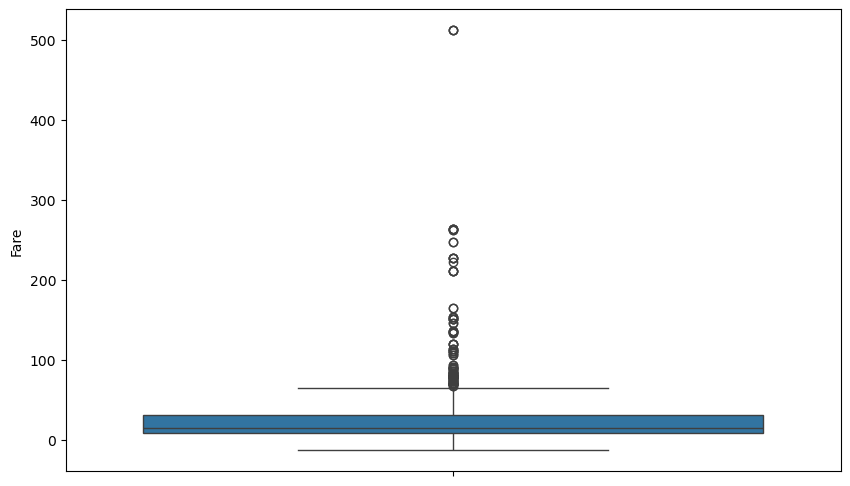

In [107]:
# Boxplot de Fare

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic["Fare"])
plt.xticks(rotation=45)
plt.show()

La variable ``Fare`` presenta una distribución claramente asimétrica hacia la derecha, lo que significa que la mayoría de los pasajeros pagó tarifas relativamente bajas, mientras que un grupo pequeño pagó precios mucho más altos.

La mediana, que es la línea dentro de la caja, se encuentra aproximadamente entre 14 y 15, por lo que la mitad de los pasajeros pagó menos que esa cantidad y la otra mitad más. En cuanto a los cuartiles, el primer cuartil (Q1) parece estar cerca de 8, lo que indica que el 25% de los pasajeros pagó esa tarifa o menos. El tercer cuartil (Q3) está alrededor de 31, así que el 75% de los pasajeros pagó hasta ese valor. Esto significa que el 50% central de las tarifas se concentra aproximadamente entre 8 y 31.

Los bigotes muestran el rango de valores que no se consideran atípicos según la regla del boxplot. A partir de ahí, aparecen muchísimos outliers por encima del bigote superior, con tarifas que suben muy por encima de 100 e incluso llegan a más de 500. Esto indica que existían algunos billetes extremadamente caros, pero eran casos poco frecuentes en comparación con la mayoría. Por eso, la distribución está muy concentrada en valores bajos y medios, con una cola larga hacia valores altos.

También se observa que el bigote inferior baja incluso por debajo de 0, pero eso no significa necesariamente que haya tarifas negativas en los datos; simplemente es el alcance visual del boxplot según la escala y la forma en que se calculan los límites. En la práctica, una tarifa negativa no tendría sentido económico, así que si existiera en el dataset sería un error.

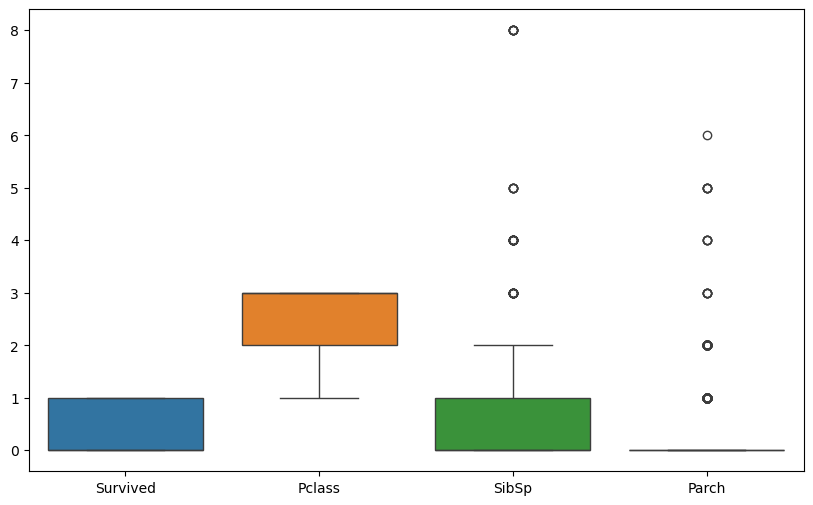

In [108]:
# Boxplots del resto

num_restantes = ['Survived', 'Pclass', 'SibSp', 'Parch']

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic[num_restantes])
plt.show()


``Survived``
Esta variable es binaria, así que el boxplot aquí no es tan informativo como en variables continuas. La caja va básicamente entre 0 y 1, lo que refleja que en el dataset hay tanto personas que no sobrevivieron (0) como personas que sí sobrevivieron (1). La mediana parece estar cerca de 0, lo que sugiere que hubo más personas que no sobrevivieron que personas que sí. En este caso no tiene mucho sentido hablar de outliers, porque solo existen dos valores posibles.

``Pclass``
La variable Pclass toma los valores 1, 2 y 3, donde 1 es primera clase y 3 es tercera. La caja está aproximadamente entre 2 y 3, y la mediana parece alrededor de 3. Esto indica que una gran parte de los pasajeros viajaba en clases bajas, especialmente en tercera clase. Los bigotes llegan hacia 1 y 3, pero no aparecen outliers porque todos los valores posibles están dentro del rango natural de la variable. Aquí el boxplot sirve más para ver concentración que para detectar atípicos.

``SibSp``
En SibSp se observa que la caja está entre 0 y 1, con una mediana muy cercana a 0. Esto significa que la mayoría de los pasajeros viajaba sin hermanos/esposos a bordo, o como mucho con 1 acompañante de este tipo. Los valores más altos, como 3, 4, 5 y especialmente 8, aparecen como outliers, lo que indica que eran casos poco frecuentes. En otras palabras, viajar con varios hermanos o cónyuges era inusual en comparación con el comportamiento general del dataset.

``Parch``
En Parch la caja está prácticamente concentrada en 0, y la mediana también es 0. Esto muestra que la mayoría de los pasajeros viajaba sin padres ni hijos a bordo. Los valores de 1 en adelante aparecen como posibles outliers, lo que sugiere que viajar acompañado de padres o hijos era menos común. También puede reflejar que muchos pasajeros viajaban solos, o que en algunos casos los niños iban con niñera y por eso seguían apareciendo con Parch = 0

### Tratamiento de Outliers

Para Age:

Vamos a quitar aquellos individuos que tienen una edad menor a 0, lo cual es imposible. Esto muestra que el outlier no es porque es un valor atipico, sino que es un error. 

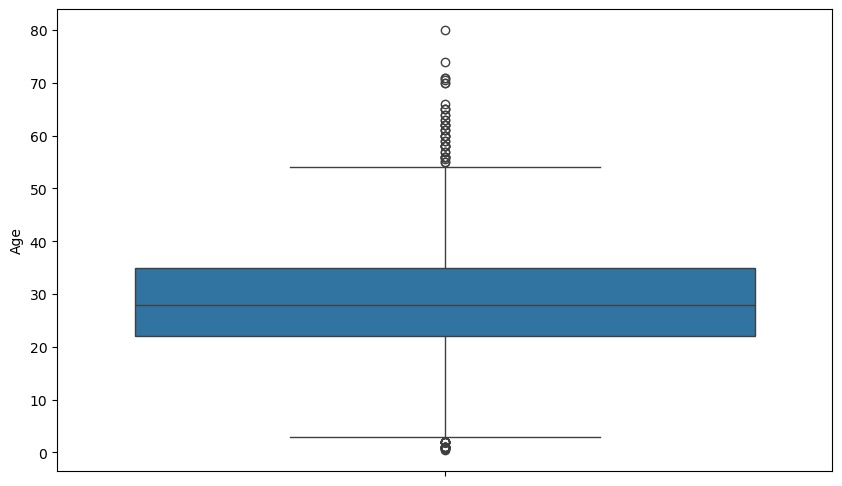

In [109]:
Titanic = Titanic[Titanic["Age"] >= 0]

plt.figure(figsize=(10, 6))
sns.boxplot(data=Titanic["Age"])
plt.xticks(rotation=45)
plt.show()


Ya el resto de outliers no los quitamos, ya que no son edades poco realistas. Osea, despues de quitar edades negativas, no vemos edades como 130 años, muy raras o casi imposibles. 

Para la variable Fare, Vamos a dejar los outliers. Esto es porque vemos que los outliers son precios de pasajeros que tenían una tarifa más alta quizas por el tipo de ticket, o cuarto, etc... Por lo que, para no quitarlos, vamos a clasificarlos como "tarifas normales" si estan dentro de los rangos noramles, y si estan fueran, entonces clasificarlos como "tarifas elevadas". Asi, no se eliminan, pero se llegan a clasificar y monitorear. 

In [110]:
Titanic["Tipo_Tarifa"] = np.where(
    Titanic["Fare"] > 100,
    "Tarifa Elevada",
    "Tarifa Normal"
)

Titanic[["Fare", "Tipo_Tarifa"]].head()

/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/4279715505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Titanic["Tipo_Tarifa"] = np.where(


,Fare,Tipo_Tarifa
0,7.2500,Tarifa Normal
1,71.2833,Tarifa Normal
2,7.9250,Tarifa Normal
3,53.1000,Tarifa Normal
4,8.0500,Tarifa Normal


# 5.- Filtrado Y Agregaciones (3 puntos)

In [111]:
num_duplicados = Titanic.duplicated().sum()
print(f"Filas duplicadas encontradas: {num_duplicados}")

Filas duplicadas encontradas: 0


In [112]:
duplicados = Titanic[Titanic.duplicated(keep=False)]
print(f"\nRegistros que forman duplicados ({len(duplicados)} filas):")
duplicados


Registros que forman duplicados (0 filas):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Barco,Tipo_Tarifa


In [113]:
df_male = Titanic[Titanic["Sex"] == "male"]
df_female = Titanic[Titanic["Sex"] == "female"]

agrupado1 = df_male.groupby("Pclass")["Age"].agg(
    mediana="median",
    minima="min",
    maxima="max"
)

agroupado2 = df_male.groupby("Pclass")["Fare"].agg(
    Tarifa_media="median",
    desviacion_std="std"
)


agrupado3 = df_female.groupby("Pclass")["Age"].agg(
    mediana="median",
    minima="min",
    maxima="max"
)

agroupado4 = df_female.groupby("Pclass")["Fare"].agg(
    Tarifa_media="median",
    desviacion_std="std"
)

print(agrupado1)
print(agroupado2)
print(agrupado3)
print(agroupado4)

        mediana  minima  maxima
Pclass                         
1          36.0    0.92    80.0
2          29.0    0.67    70.0
3          28.0    0.42    74.0
        Tarifa_media  desviacion_std
Pclass                              
1            41.2625       77.548021
2            13.0000       15.238397
3             7.9250       11.731676
        mediana  minima  maxima
Pclass                         
1          32.5    2.00    63.0
2          28.0    2.00    57.0
3          28.0    0.75    63.0
        Tarifa_media  desviacion_std
Pclass                              
1           82.66455       74.259988
2           21.00000       10.722355
3           12.47500       11.690314


Cuando divivimos nuestros datos en subbconjuntos de hombres y mujeres y los agrupamos con otros atributos podemos podemos ver cosas como: 

- Cuando agrupamos hombres con la clase de su billete y su edad, podemos ver que la clase que tiene las tendencias mas bajas es la tercera clase del billete. Ya que esta misma clase tiene la mediana y minima más baja de entre los tres grupos de clase con 28 años y 0.42 años. A pesar de que su diferenica con la segunda clase que es bastante pequeña en torno a las tres categorías, notamos esta tendencia. Esto tambien nos dice que la primera clase es la que tiene la edad media, minima y maxima mas alta de entre los tres grupos con 36, 0.92 y 80 años respectivamente. Esto nos muestra la diferencia de clases y la distribución de sus integrantes hombres. Los hombres conmayor edad usualmente iban en primera clase.

- De la misma manera cuando agrupamos hombres con su clase de billete y la tarifa media con su desviacion estandar, vemos que la tarifa media se mantiene más baja en la tercera clase con 7.93$ y esto lo lleva a tener una diferenica de alrededor de 38$ con la primera clase, ya que vale 41.26$. Esto nos muestra la diferncia abrumante de clases abordo del Titanic. Aún más, vemos que en la desviación estandar de la primera clase la tiene en 77.54 a diferenica de la segunda y tercera clase que estan en 15.24 y 11.73 respectivamente esto nos muestra que en la primera clase hay una alta dispersión, en la segunda hay una dispersión moderada y en la tercera los datos están muy agrupados por su baja dispersión.

- Por el otro lado cuando agrupamos a las mujeres con la clase de su billete y su edad, vemos una tendencia más cerrada que la de los hombres. Vemos que la edad media de la primera y segunda clase es de 28 años y la de primera clase es de 32.5, son solo 4 años de diferenica de edad minima. Tambíen vemos que la edad minima de las mujeres es más alta que la de los hombres en las tres categorías. Por último, la edad maxima se mantiene en 63 años para la tercera y primera clase mientras que la segunda llega a los 57 años. Estos datos nos muestran que la diferncia de edades entre mujeres abordo del Titanic no fue tan abrumante como fue el caso de los hombres.

- Por último, cuando agrupamos a las mujeres con su tarifa media y la desviación estandar, divisamos que las tarifas de la primera y segunda clase fueron mucho más altas que las de los hombres. Ya que la primera clase de la mujer llevaba una tarifa media de 84$  y la de segunda de 21$. De igual manera, la desviación estandar en la primera clase fue de 74.2, este numero viene a ser bastante grande y muestra que hubo mucha dispersion en el precio de la tarifa media de la primera clase, mientras que la segunda llevaba 10.7 y la tercera 11.7, esto lo podemos considerar moderado y que en estas clases los precios estaban más concentrados.

En conclusión, con la información de esta parte podemos ver que hay mucha dispersion en el precio de los billetes para ambos hombres y mujeres de la primera clase, pero ya despues llegan asimilarse en la tercera clase. Sin embargo, hay una gran diferencia en la tendencia de clases dentro de los hombres que para las mujeres. 

In [114]:
df_total = pd.concat([df_male, df_female], ignore_index=True)

agroupado_total = df_total.groupby(["Pclass", "Sex"]).agg(
    Total_pasajeros=("PassengerId", "count"),
    Sobrevivientes=("Survived", "sum")
).reset_index()

agroupado_total["% de Sobrevivencia"] = round(
    (agroupado_total["Sobrevivientes"] / agroupado_total["Total_pasajeros"]) * 100, 2
)

print(agroupado_total)


   Pclass     Sex  Total_pasajeros  Sobrevivientes  % de Sobrevivencia
0       1  female               94              91               96.81
1       1    male              122              45               36.89
2       2  female               75              69               92.00
3       2    male              108              17               15.74
4       3  female              144              72               50.00
5       3    male              347              47               13.54


En la tabla de arriba podemos ver una comparación agrupada de hombres y mujeres por clase y su respectivo porcentaje de sobrevivencia. Vemos como hay un abrumante 96.81% de sobrevivencia de las mujeres de la primera clase, es decir solo 3 no lograron sobrevivir. También vemos que las mujeres de la segunda y tercera clase tienen porcentajes que son de igualmente altos, con un 92% y 50% respectivamente. 

A comparación de los hombres abordo donde el porcentaje más alto para ellos fue el grupo de primera clase con 36.89%. Los groupos de segunda y tercera clase llegaron a 15.74 y 13.54. Estos datos nos dicen lo que ya nos decia nuestra primera práctica, que se les dio prioridad a las mujeres al momento de la evacuación del Titanic por ende lograron sobrevivir más. Otra cosa que podemos discutir es que abordo del Titanc había muchos más hombres que mujeres, sin embargo sobrevivieron más las mujeres aún asi.

In [115]:
Titanic["Grupo_Edad"] = pd.cut(Titanic["Age"], bins=[0, 12, 18, 60, 80], labels=["Niño", "Adolescente", "Adulto", "Mayor"])
round(Titanic.groupby("Grupo_Edad")["Survived"].mean() * 100,2)


/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/3623162584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Titanic["Grupo_Edad"] = pd.cut(Titanic["Age"], bins=[0, 12, 18, 60, 80], labels=["Niño", "Adolescente", "Adulto", "Mayor"])
/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/3623162584.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  round(Titanic.groupby("Grupo_Edad")["Survived"].mean() * 100,2)


Grupo_Edad
Niño           57.35
Adolescente    42.86
Adulto         36.58
Mayor          22.73
Name: Survived, dtype: float64

Aqui agrupamos nuestros datos por grupo de edad y sobrevivenica. Con estos datos podemos ver si este fue un factor determinante en sobrevivir al Titanic. Podemos ver que el grupo de los niños conformaron la sobreviviencia más alta abordo del Titanic con un 57.35 %. Es decir, más o menos uno de cada dos niños sobrevivio al Titanic. Mientras vamos subiendo de edades la sobrevivencia baja, los adolescentes llevan el 42.86 %, los adultos 36.58 % y los mayores un 22.73 %. Esto nos dice que la edad en efecto fue un factor determinante para sobrevivir al Titanic y mientras la edad de un pasajero era menor, tenia mas probabilidades de sobrevivir.

In [116]:
Titanic["Tamaño_Familia"] = Titanic["SibSp"] + Titanic["Parch"] + 1
round(Titanic.groupby("Tamaño_Familia")["Survived"].mean() * 100,2)


/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/1674058699.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Titanic["Tamaño_Familia"] = Titanic["SibSp"] + Titanic["Parch"] + 1


Tamaño_Familia
1     30.35
2     55.28
3     57.84
4     71.43
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64

En la tabla de arriba agrupamos el tamaño de la familia con la sobrevivencia al Titanic. Notamos que la personas que viajaban solas tenian un porcentaje de sobrevivencia del 30.35 %. Mientras que las familias de 2, 3 y 4 integrantes tenian los porcentajes de sobrevivencia más altos con 55.28%, 57.84% y 71.43% respectivamente. Pero las familias ya más grandes que esto como las de 5, 6 y 7 personas tuvieron una baja sobrevivencia. Estos datos nos dicen que una familia más grande no necesariamente nos da una oportunidad de sobrevivencia mejor, pero una familia de 2, 3 o 4 personas si que da una probabilidad de sobrevivencia más alta que el resto.

In [117]:
Titanic.groupby(["Pclass", "Embarked"])["Survived"].agg(
    total_pasajeros="count",
   sobrevivientes="sum",
    tasa_sobrevivencia=lambda x: round(x.mean() * 100, 2)
).reset_index()


,Pclass,Embarked,total_pasajeros,sobrevivientes,tasa_sobrevivencia
0,1,C,85,59,69.41
1,1,Q,2,1,50.00
2,1,S,129,76,58.91
3,2,C,16,8,50.00
4,2,Q,3,2,66.67
5,2,S,164,76,46.34
6,3,C,66,25,37.88
7,3,Q,72,27,37.50
8,3,S,353,67,18.98


En la tabla que se muestra arriba agrupamos las diferentes clases de los distintos sitios de embarcación para ver cuantos pasajeros embarcaron en cada lugar, cuantos sobreviveron de ellos y medimos la tasa de sobrevivencia. 

Con esto podemos ver que las personas con una tasa de sobrevivencia mayor fueron aquellos que embarcaron en Cherbourg en primera clase, de estos sobrevivio el 69.41%. Sorprendentemente el grupo de pasajeros que más sobrevivio despúes de ellos fueron aquellos de la segunda clase que embarcaron en Queenstown con un 66.67%. Despues de esto le sigue la primera clase de Southhampton con un 58.91% y la primera clase de Queenstown con un 50%. 

Despúes vemos que el grupo de personas que menos sobrevivio con diferencia fueron los que componian la tercera clase de Southhampton con un 18.98% es decir solo sobrevivieron 67 personas de 353. Antes de ellos la clase que menos sobrevivio fue la tercera clase de Queenstown con un 37.5%.

Estos datos tambien hay que analizarlos desde otra perspectiva. Si bien puede ser que la clase y el lugar de embarcación pudo haber tenido influencia al momento de sobrevivir. Los pasajeros de las clases inferiores componian una parte mayor de los pasajeros totales que aquellos que componian las clases altas. 

In [118]:
Titanic.groupby(["Tipo_Tarifa", "Pclass"])["Survived"].agg(
    total=("count"),
    sobrevivientes=("sum"),
    tasa_sobrevivencia=lambda x: round(x.mean() * 100, 2)
)


total  sobrevivientes  tasa_sobrevivencia
Tipo_Tarifa    Pclass                                           
Tarifa Elevada 1          53              39               73.58
Tarifa Normal  1         163              97               59.51
               2         183              86               46.99
               3         491             119               24.24

En esta tabla analizamos la relación de el tipo de Tarifa en relación a la clase del pasajero y vemos su % de sobrevivencia. La primera fila representa los billetes que valian mas de 100$ en primera clase, este grupo lleva el mayor porcentaje de sobrevivencia por muy lejos con un 73.58%. Despues de este grupo vemos que las distancias del porcentaje se comienzan a reucir entre el grupo de primera clase donde sus pasajes valian menos de 100$ y dela segunda clase donde su diferenica es de alrededor de 13%. Por último vemos que el grupo con menos porcentaje de sobrevivencia fueron aquellos que componian la tercera clase con un 24.4%.

Sin emabrgo, de nuevo, sin nos fijamos en la cantidad mas allá de los porcentajes, divisamos que la clase que tuvo mas sobrevivientes en general fue la tercera clase con 199 personas, aunque es verdad que en relación a su total conforman apenas ese 24.4%. 

In [119]:
round(Titanic.groupby(["Sex", "Grupo_Edad"])["Survived"].mean() * 100,2)


/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/25312038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  round(Titanic.groupby(["Sex", "Grupo_Edad"])["Survived"].mean() * 100,2)


Sex     Grupo_Edad 
female  Niño            58.06
        Adolescente     75.00
        Adulto          75.72
        Mayor          100.00
male    Niño            56.76
        Adolescente      8.82
        Adulto          17.04
        Mayor           10.53
Name: Survived, dtype: float64

En esta tabla se lorgo analizar el agrupamiento de sexo con grupo de edad y su porcentaje de sobrevivencia. Vemos que aqui las mujeres mayores sobreviveron al 100%, esto le sigue por las mujeres adultas que el 75.72% sobrevivio y las niñas tambien que sobreviveron en un 58.06%. Estos datos nos dicen que las mujeres en general en comparación a los hombres tuvieron preferencia al momento de sobrevivir el Titanic. A comparación de los hombres donde los hombres adolecsentes apenas sobrevivieron el 8.82 %, el adulto 17.04% y el mayor con 10.53%.

# 6.- Uniones (1 punto)

In [120]:
Weather = Weather.rename(columns={"Nombre_Barco":"Barco"})

Titanic["Barco"] = Titanic["Barco"].replace("Titanic", "TITANIC")

clima_titanic =pd.merge(Titanic, Weather, on = "Barco")

clima_titanic = clima_titanic.drop(columns=["Ship_ID", "Tripulantes", "Barco", ])


clima_titanic

/var/folders/fk/mn26c1tn2hvf70vk6jp8s9b00000gn/T/ipykernel_821/4016767913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Titanic["Barco"] = Titanic["Barco"].replace("Titanic", "TITANIC")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Tipo_Tarifa,Grupo_Edad,Tamaño_Familia,Fecha_Salida,Clima,TemperaturaMedia
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
886,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
887,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Tarifa Normal,Adulto,4,1912-04-10,Despejado,2.0
888,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0


Despúes de unir ambos datasets y analizarlos, concluyo que las variables del dataset de Weather como Clima, Temperatura media, Fecha de salida y Tripulantes tienen muy poco valor predictivo. Asi queramos crear un modelo predictivo de supervivencia, el clima y la temperatura media son evidentemente los mismos para todos los pasajeros por ende no aporta mucho. La Fecha de salida viene a ser la misma para todos por ende no se puede analizar tampoco. Con el atributo Tripulantes se cuenta la tripulación del barco y esto no tiene relación directa con la supervivencia del pasajero. Para terminar, el atributo de Barco y Ship_ID es solo para un barco del dataset asi que es totalmente reduntante. Por eso no nos sirve de mucho el dataset de Weather, evidentemente todos los pasajeros comparten los mismos datos ya que todos iban abordo del mimso barco.

# 7.- Conclusion Final (1 punto)

In [121]:
clima_titanic.to_csv("Titanic_limpio.csv", index=False)


pd.read_csv("Titanic_limpio.csv")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Tipo_Tarifa,Grupo_Edad,Tamaño_Familia,Fecha_Salida,Clima,TemperaturaMedia
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Tarifa Normal,Adulto,2,1912-04-10,Despejado,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
886,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0
887,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Tarifa Normal,Adulto,4,1912-04-10,Despejado,2.0
888,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Tarifa Normal,Adulto,1,1912-04-10,Despejado,2.0


En cuanto a la calidad de datos detectados podemos decir que gracias a que no hubo filas duplicadas ni redundancias en el dataset del Titanic fue un análisis bastante limpio. Hay tendencias muy claras e intereseantes como vimos en la práctica anterior y en esta práctica. Debido a esto vemos claramente que las mujeres tienen preferencia al momento de sobrevivir la tragedia del Titanic frente a los hombres, aunque es verdad que habian menos mujeres abordo a comparación de hombres. Tambien en cuanto al dataset de Weather podemos decir, como he dicho antes, es bastante inútil, no nos cuenta mucho ya que es la misma información para todos los pasajeros abordo del mismo barco. Si hubiese sido un dataset con más datos que contrasten entre los pasajeros nos pudiese haber proporcionado de más valor para un análisis predictivo.